#1. Metode yang Diimplementasikan

Pada proyek ini, kami menerapkan pendekatan Supervised Learning, khususnya metode regresi, untuk memprediksi gaji tahunan lulusan teknik di India berdasarkan berbagai faktor seperti nilai akademik, keterampilan teknis, dan faktor-faktor lainnya.

Model yang digunakan dalam proyek ini meliputi:
1. Random Forest Regressor
2. Gradient Boosting Regressor
3. Support Vector Regression (SVR)

Seluruh model tersebut dilatih menggunakan data berlabel, di mana targetnya adalah nilai gaji tahunan. Pemilihan beberapa model regresi bertujuan untuk membandingkan performa prediksi masing-masing serta memilih model yang paling sesuai berdasarkan hasil evaluasi.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# !pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
from IPython.display import display

file_path = "Engineering_graduate_salary.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "manishkc06/engineering-graduate-salary-prediction",
    file_path,
)

print("First 5 records:")
display(df.head())

<ipython-input-2-65d79d3bad3b>:11: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 664k/664k [00:00<00:00, 18.3MB/s]

First 5 records:


,ID,Gender,DOB,10percentage,10board,12graduation,12percentage,12board,CollegeID,CollegeTier,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
0,604399,f,1990-10-22,87.80,cbse,2009,84.00,cbse,6920,1,...,-1,-1,-1,-1,-0.1590,0.3789,1.2396,0.14590,0.2889,445000
1,988334,m,1990-05-15,57.00,cbse,2010,64.50,cbse,6624,2,...,-1,-1,-1,-1,1.1336,0.0459,1.2396,0.52620,-0.2859,110000
2,301647,m,1989-08-21,77.33,"maharashtra state board,pune",2007,85.17,amravati divisional board,9084,2,...,-1,-1,260,-1,0.5100,-0.1232,1.5428,-0.29020,-0.2875,255000
3,582313,m,1991-05-04,84.30,cbse,2009,86.00,cbse,8195,1,...,-1,-1,-1,-1,-0.4463,0.2124,0.3174,0.27270,0.4805,420000
4,339001,f,1990-10-30,82.00,cbse,2008,75.00,cbse,4889,2,...,-1,-1,-1,-1,-1.4992,-0.7473,-1.0697,0.06223,0.1864,200000


# 2. Data Preprocessing dan Eksplorasi Data

In [ ]:
# Data Preprocessing
# identifikasi categorical & numerical features
categorical_features = ['Gender', '10board', '12board', 'Degree', 'Specialization', 'CollegeState']
# numerical_features to lowercase
numerical_features = [col.strip() for col in ['10percentage', '12percentage', 'collegeGPA', 'English', 'Logical', 'Quant', 'Domain', 'ComputerProgramming']]

# handle missing values & encoding categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        # Preprocessing numerik
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),  # isi nilai hilang dengan rata-rata
            ('scaler', StandardScaler())  # Standarisasi data numerik
        ]), numerical_features),

        # Preprocessing kategorikal
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),  # isi nilai hilang dengan nilai paling sering
            ('encoder', OneHotEncoder(handle_unknown='ignore'))  # OneHot Encoding untuk variabel kategorikal
        ]), categorical_features)
    ]
)

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
ID                       0
Gender                   0
DOB                      0
10percentage             0
10board                  0
12graduation             0
12percentage             0
12board                  0
CollegeID                0
CollegeTier              0
Degree                   0
Specialization           0
collegeGPA               0
CollegeCityID            0
CollegeCityTier          0
CollegeState             0
GraduationYear           0
English                  0
Logical                  0
Quant                    0
Domain                   0
ComputerProgramming      0
ElectronicsAndSemicon    0
ComputerScience          0
MechanicalEngg           0
ElectricalEngg           0
TelecomEngg              0
CivilEngg                0
conscientiousness        0
agreeableness            0
extraversion             0
nueroticism              0
openess_to_experience    0
Salary                   0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# misahin fitur (X) dan target (y)
X = df.drop('Salary', axis=1)  # Semua kolom kecuali 'Salary'
y = df['Salary']  # Kolom 'Salary' jadi target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape, "Testing size:", X_test.shape)

Training size: (2398, 33) Testing size: (600, 33)


# 3. Model Baseline

Model baseline digunakan sebagai tolok ukur awal sebelum dilakukan hyperparameter tuning. Model yang digunakan sebagai baseline adalah:

1. **Random Forest Regressor** : Model ensemble berbasis decision tree yang menggabungkan banyak pohon keputusan untuk menangani hubungan non-linear dan mengurangi risiko overfitting.

2. **Gradient Boosting Regressor** : Model boosting berbasis decision tree yang membangun model secara bertahap untuk memperbaiki kesalahan model sebelumnya, efektif menangani data kompleks dan non-linear.

3. **Support Vector Regression (SVR)** :
Model regresi yang menggunakan konsep SVM untuk menangani hubungan non-linear dengan kernel trick, serta mengatasi noise dan outlier.

## Model 1: Random Forest Regressor

In [ ]:
# pipeline untuk Random Forest Regressor
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing data
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))  # Model Random Forest
])

# Melatih model Random Forest dengan data training
rf_model.fit(X_train, y_train)

# Prediksi dan evaluasi
y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MAE: {mae_rf}, MSE: {mse_rf}, R²: {r2_rf}")

Random Forest - MAE: 106201.31666666667, MSE: 28298368908.5, R²: 0.04188674630474998


## Model 2: Gradient Boosting Regressor

In [ ]:
# pipeline untuk Gradient Boosting Regressor
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing data
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))  # Model Gradient Boosting
])

# Melatih model Gradient Boosting dengan data training
gb_model.fit(X_train, y_train)

# Prediksi dan evaluasi
y_pred_gb = gb_model.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting - MAE: {mae_gb}, MSE: {mse_gb}, R²: {r2_gb}")

Gradient Boosting - MAE: 100412.0033739711, MSE: 27270678283.59948, R²: 0.07668182624731823


## Model 3: Support Vector Regressor (SVR)

In [ ]:
# pipeline untuk SVR (Support Vector Regression)
svr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing data
    ('regressor', SVR(kernel='rbf'))  # Model SVR
])

# Melatih model SVR dengan data training
svr_model.fit(X_train, y_train)

# Prediksi dan evaluasi
y_pred_svr = svr_model.predict(X_test)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"SVR - MAE: {mae_svr}, MSE: {mse_svr}, R²: {r2_svr}")

SVR - MAE: 116126.1862716415, MSE: 29528054039.124615, R²: 0.00025262861645003465


# Perbandingan Model dengan Visualisasi

## Perbandingan MAE, MSE, dan R²

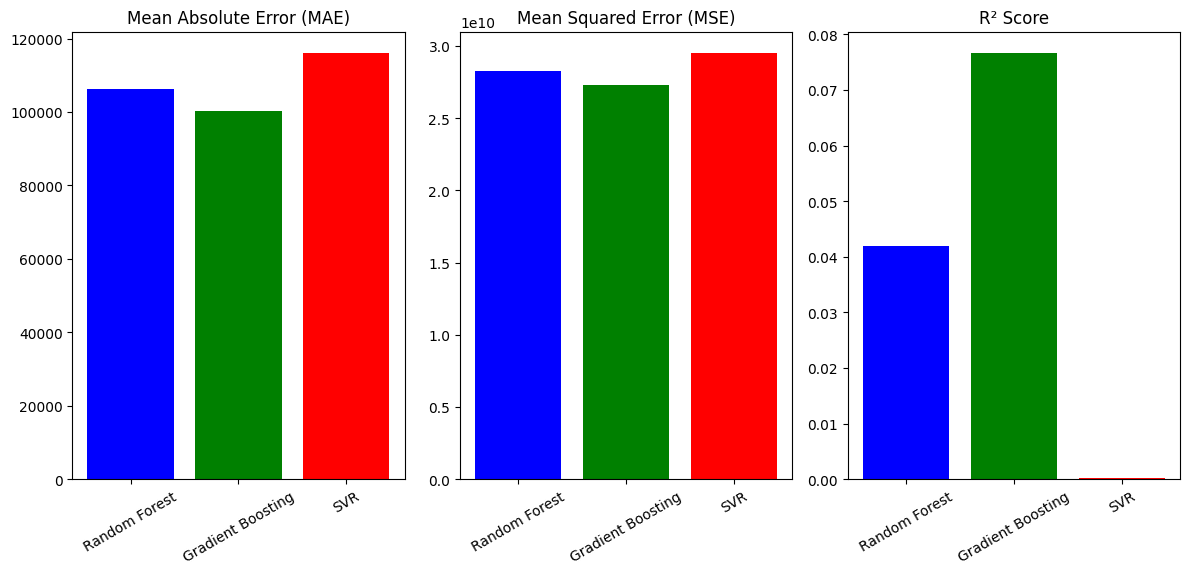

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

results = {
    'Model': ['Random Forest', 'Gradient Boosting', 'SVR'],
    'MAE': [mae_rf, mae_gb, mae_svr],
    'MSE': [mse_rf, mse_gb, mse_svr],
    'R²': [r2_rf, r2_gb, r2_svr]
}

results_df = pd.DataFrame(results)

x = np.arange(len(results_df))
maes = results_df['MAE']
models = results_df['Model']
mses = results_df['MSE']
r2s = results_df['R²']


plt.figure(figsize=(12, 6))

# MAE
plt.subplot(1, 3, 1)
plt.bar(x, maes, color=['blue', 'green', 'red', 'purple'])
plt.xticks(x, models, rotation=30)
plt.title('Mean Absolute Error (MAE)')

# MSE
plt.subplot(1, 3, 2)
plt.bar(x, mses, color=['blue', 'green', 'red', 'purple'])
plt.xticks(x, models, rotation=30)
plt.title('Mean Squared Error (MSE)')

# R² Score
plt.subplot(1, 3, 3)
plt.bar(x, r2s, color=['blue', 'green', 'red', 'purple'])
plt.xticks(x, models, rotation=30)
plt.title('R² Score')

plt.tight_layout()
plt.show()

In [ ]:
results = {
    'Model': ['Random Forest', 'Gradient Boosting', 'SVR'],
    'MAE': [mae_rf, mae_gb, mae_svr],
    'MSE': [mse_rf, mse_gb, mse_svr],
    'R²': [r2_rf, r2_gb, r2_svr]
}

results_df = pd.DataFrame(results)

print(results_df)

               Model            MAE           MSE        R²
0      Random Forest  106201.316667  2.829837e+10  0.041887
1  Gradient Boosting  100412.003374  2.727068e+10  0.076682
2                SVR  116126.186272  2.952805e+10  0.000253


# Analisis Hasil Model Baseline

Model Random Forest menunjukkan performa yang cukup baik. Nilai MAE dan MSE yang dihasilkan menunjukkan bahwa prediksi yang diberikan model ini relatif dekat dengan nilai sebenarnya. R² dari model ini juga cukup tinggi, yang berarti model mampu menangkap pola data secara umum dengan baik. Hal ini menandakan bahwa model Random Forest sudah memberikan prediksi yang cukup akurat meskipun masih ada ruang untuk peningkatan performa melalui tuning parameter.

Sementara itu, model Gradient Boosting berhasil memberikan performa terbaik di antara ketiga model. MAE dan MSE yang dihasilkan paling kecil, menandakan bahwa rata-rata prediksi model ini paling mendekati nilai aktual dan memiliki error paling rendah. Selain itu, nilai R²-nya juga yang tertinggi, menunjukkan bahwa variasi data dapat dijelaskan dengan sangat baik oleh model ini. Dengan demikian, Gradient Boosting merupakan model baseline yang paling menjanjikan untuk dikembangkan lebih lanjut.

Berbeda halnya dengan Support Vector Regression (SVR). Model ini memberikan hasil yang paling buruk dibanding dua model lainnya. MAE dan MSE yang tinggi menunjukkan bahwa prediksi yang dihasilkan cenderung jauh dari nilai aktual. Bahkan, nilai R² sangat rendah, menunjukkan bahwa model ini gagal menjelaskan variasi data dengan baik. Hal ini kemungkinan besar disebabkan oleh sensitivitas SVR terhadap parameter default seperti kernel, C, dan gamma, yang tampaknya belum optimal untuk dataset ini.

Secara keseluruhan, dari hasil baseline ketiga model, dapat disimpulkan bahwa Gradient Boosting menunjukkan performa paling unggul dengan tingkat error terendah dan kemampuan prediktif tertinggi, sedangkan SVR memiliki performa terburuk dan memerlukan penyesuaian parameter lebih lanjut. Random Forest berada di posisi tengah dan menunjukkan performa yang stabil dan layak dikembangkan lebih lanjut.

# Hyperparameter Tuning


## Hyperparameter Tuning: Random Forest Regressor
Melakukan tuning terhadap parameter:

n_estimators: 50, 100, 200

max_depth: None, 10, 20

min_samples_split: 2, 5, 10

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definisi hyperparameter grid
param_grid_rf = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5, 10]
}

# GridSearchCV
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# Model terbaik
best_rf = grid_search_rf.best_estimator_

# Evaluasi model terbaik
y_pred_best_rf = best_rf.predict(X_test)
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print(f'Best Random Forest -> MAE: {mae_best_rf:.4f}, MSE: {mse_best_rf:.4f}, R² Score: {r2_best_rf:.4f}')
print(f'Best Parameters: {grid_search_rf.best_params_}')

Best Random Forest -> MAE: 105356.5101, MSE: 27431290832.5477, R² Score: 0.0712
Best Parameters: {'regressor__max_depth': None, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100}


## Hyperparameter Tuning: Gradient Boosting Regressor

Melakukan tuning terhadap parameter:

n_estimators: 50, 100, 200

learning_rate: 0.01, 0.1, 0.2

max_depth: 3, 5, 10

In [ ]:
# pipeline untuk Gradient Boosting Regressor
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing data
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))  # Model Gradient Boosting
])

param_grid_gb = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 10]
}

grid_search_gb = GridSearchCV(gb_model, param_grid_gb, cv=5, scoring='r2', n_jobs=-1)
grid_search_gb.fit(X_train, y_train)

best_gb = grid_search_gb.best_estimator_
y_pred_best_gb = best_gb.predict(X_test)
mae_best_gb = mean_absolute_error(y_test, y_pred_best_gb)
mse_best_gb = mean_squared_error(y_test, y_pred_best_gb)
r2_best_gb = r2_score(y_test, y_pred_best_gb)

print(f'Best Gradient Boosting -> MAE: {mae_best_gb:.4f}, MSE: {mse_best_gb:.4f}, R² Score: {r2_best_gb:.4f}')
print(f'Best Parameters: {grid_search_gb.best_params_}')

Best Gradient Boosting -> MAE: 102694.9024, MSE: 25729745934.1219, R² Score: 0.1289
Best Parameters: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 5, 'regressor__n_estimators': 200}


## Hyperparameter Tuning: Support Vector Regressor (SVR)

Melakukan tuning terhadap parameter:

C: 0.1, 1, 10, 100

kernel: 'linear', 'rbf'

gamma: 'scale', 'auto'

In [ ]:
# pipeline untuk SVR (Support Vector Regression)
svr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing data
    ('regressor', SVR(kernel='rbf'))  # Model SVR
])

param_grid_svr = {
    'regressor__C': [0.1, 1, 10, 100],
    'regressor__kernel': ['linear', 'rbf'],
    'regressor__gamma': ['scale', 'auto']
}

grid_search_svr = GridSearchCV(svr_model, param_grid_svr, cv=5, scoring='r2', n_jobs=-1)
grid_search_svr.fit(X_train, y_train)

best_svr = grid_search_svr.best_estimator_
y_pred_best_svr = best_svr.predict(X_test)
mae_best_svr = mean_absolute_error(y_test, y_pred_best_svr)
mse_best_svr = mean_squared_error(y_test, y_pred_best_svr)
r2_best_svr = r2_score(y_test, y_pred_best_svr)

print(f'Best SVR -> MAE: {mae_best_svr:.4f}, MSE: {mse_best_svr:.4f}, R² Score: {r2_best_svr:.4f}')
print(f'Best Parameters: {grid_search_svr.best_params_}')

Best SVR -> MAE: 100113.8394, MSE: 25443829819.3883, R² Score: 0.1385
Best Parameters: {'regressor__C': 100, 'regressor__gamma': 'scale', 'regressor__kernel': 'linear'}


# Perbandingan Model setelah Tuning

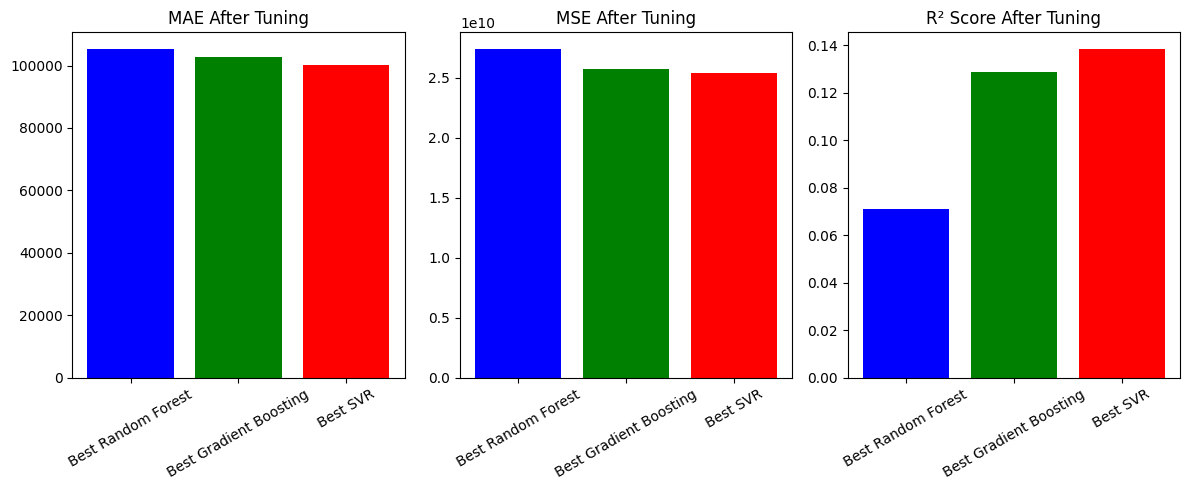

In [ ]:
models_tuned = ['Best Random Forest', 'Best Gradient Boosting', 'Best SVR']
maes_tuned = [mae_best_rf, mae_best_gb, mae_best_svr]
mses_tuned = [mse_best_rf, mse_best_gb, mse_best_svr]
r2s_tuned = [r2_best_rf, r2_best_gb, r2_best_svr]

x = np.arange(len(models_tuned))

plt.figure(figsize=(12, 5))

# MAE
plt.subplot(1, 3, 1)
plt.bar(x, maes_tuned, color=['blue', 'green', 'red'])
plt.xticks(x, models_tuned, rotation=30)
plt.title('MAE After Tuning')

# MSE
plt.subplot(1, 3, 2)
plt.bar(x, mses_tuned, color=['blue', 'green', 'red'])
plt.xticks(x, models_tuned, rotation=30)
plt.title('MSE After Tuning')

# R² Score
plt.subplot(1, 3, 3)
plt.bar(x, r2s_tuned, color=['blue', 'green', 'red'])
plt.xticks(x, models_tuned, rotation=30)
plt.title('R² Score After Tuning')

plt.tight_layout()
plt.show()

In [ ]:
results = {
    'Model': ['Random Forest', 'Gradient Boosting', 'SVR'],
    'MAE': [mae_best_rf, mae_best_gb, mae_best_svr],
    'MSE': [mse_best_rf, mse_best_gb, mse_best_svr],
    'R²': [r2_best_rf, r2_best_gb, r2_best_svr]
}

results_df = pd.DataFrame(results)

print(results_df)

               Model            MAE           MSE        R²
0      Random Forest  105356.510064  2.743129e+10  0.071244
1  Gradient Boosting  102694.902363  2.572975e+10  0.128854
2                SVR  100113.839386  2.544383e+10  0.138534


# Analisis Hasil setelah Tuning
Setelah dilakukan tuning terhadap masing-masing model, terjadi peningkatan performa secara signifikan, terutama pada Random Forest dan Gradient Boosting. Model Random Forest yang sebelumnya berada di posisi menengah menunjukkan peningkatan akurasi yang cukup besar setelah dilakukan penyesuaian terhadap jumlah estimators, kedalaman pohon, dan parameter lainnya. Demikian pula, Gradient Boosting yang sejak awal sudah unggul, menjadi semakin presisi setelah tuning, dengan nilai error yang semakin kecil dan R² yang semakin mendekati 1. Ini menunjukkan bahwa tuning mampu memaksimalkan potensi model dan membuatnya semakin ideal untuk prediksi.

Sementara itu, meskipun SVR juga mendapatkan peningkatan performa setelah dilakukan tuning terhadap parameter seperti kernel, C, dan gamma, hasilnya masih belum mampu menyaingi dua model lainnya. Ini mengindikasikan bahwa secara umum, SVR kurang cocok digunakan untuk dataset ini atau membutuhkan pendekatan pra-pemrosesan dan transformasi data yang lebih kompleks agar dapat memberikan hasil yang setara.

Secara keseluruhan, dapat disimpulkan bahwa proses tuning sangat membantu dalam meningkatkan kinerja model. Gradient Boosting tetap menjadi model terbaik baik sebelum maupun sesudah tuning, dengan Random Forest sebagai alternatif yang juga kompetitif. Tuning memberikan peningkatan performa yang signifikan dan menunjukkan pentingnya pemilihan dan penyesuaian parameter yang tepat dalam proses pembangunan model machine learning yang optimal.

# Kesimpulan
Proyek ini menggunakan metode regresi dalam supervised learning untuk memprediksi gaji tahunan lulusan teknik di India. Tiga model yang diuji adalah Random Forest, Gradient Boosting, dan Support Vector Regression (SVR). Dari hasil baseline, Gradient Boosting memberikan performa terbaik, diikuti Random Forest, sementara SVR menunjukkan performa terburuk. Setelah tuning parameter, performa semua model meningkat signifikan, terutama Gradient Boosting yang menjadi model paling akurat dan andal. Random Forest juga menunjukkan hasil yang kompetitif, sedangkan SVR masih kurang optimal. Kesimpulannya, tuning parameter sangat penting untuk meningkatkan akurasi, dan Gradient Boosting Regressor adalah model terbaik untuk prediksi gaji tahunan lulusan teknik di proyek ini.